# Maven Market Data Audit

This notebook profiles the eight raw Maven Market files before any cleaning is applied. It checks schema, completeness, duplicates, date coverage, business rules, and relationships between tables.

The notebook writes the detailed outputs to `reports/` through the reusable `scripts/data_audit.py` module.

## tl;dr

- The raw data is usable for the project and all tested foreign-key relationships are valid.
- A total-company 1998 vs 1997 comparison is not like-for-like: store coverage increases from 13 to 24 stores.
- The fact files have no order, transaction, or return identifier, so exact-looking duplicate rows cannot be removed safely.
- Product flag blanks are encoded false values, not unknown product attributes.
- Dates and identifier fields need explicit types during cleaning.

## Context & Methods

The expected transaction grain is one product/customer/store/date sales row. The source does not provide a receipt or order identifier, so this grain cannot be proven at order level.

Checks cover:

- row and column counts
- raw data types
- missing values
- exact-looking duplicate rows
- primary and foreign key coverage
- date ordering and coverage
- positive quantity, cost, price, weight, and area rules
- customer and store cross-field rules
- active vs inactive dimension members

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))
from scripts.data_audit import run_audit

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 100)

results = run_audit(PROJECT_ROOT, write_outputs=True)
results["summary"]

{'raw_files': 8,
 'transaction_rows': 269720,
 'return_rows': 7087,
 'customers': 10281,
 'products': 1560,
 'stores': 24,
 'calendar_start': '1997-01-01',
 'calendar_end': '1998-12-31',
 'high_findings': 3,
 'medium_findings': 5,
 'low_findings': 5,
 'integrity_checks_failed': 0}

## Data

### 1. Table profile

In [2]:
table_profile = results["table_profile"]
table_profile

,table,rows,columns,missing_cells,missing_cell_rate_pct,exact_duplicate_rows,exact_duplicate_rate_pct
0,calendar,730,1,0,0.0000,0,0.0000
1,customers,10281,20,1,0.0005,0,0.0000
2,products,1560,9,1695,12.0726,0,0.0000
3,regions,109,3,0,0.0000,0,0.0000
4,returns,7087,4,0,0.0000,5,0.0706
5,stores,24,13,0,0.0000,0,0.0000
6,transactions_1997,86837,6,0,0.0000,1,0.0012
7,transactions_1998,182883,6,0,0.0000,8,0.0044


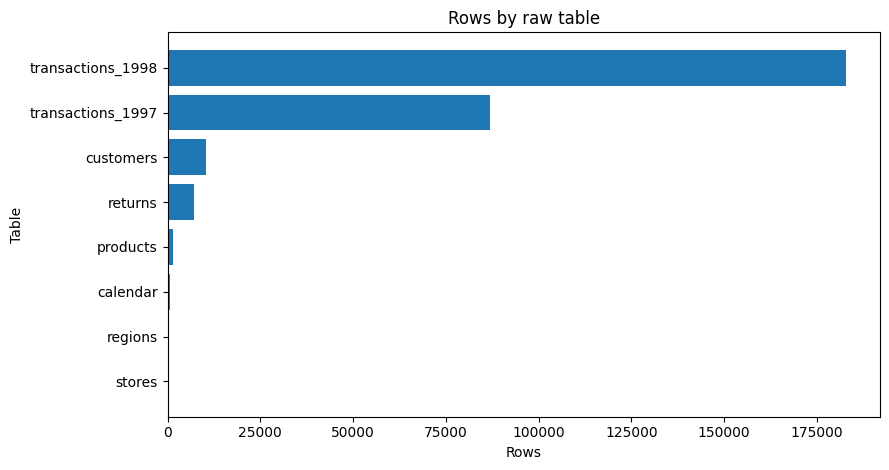

In [3]:
plot_data = table_profile.sort_values("rows")
plt.figure(figsize=(9, 4.8))
plt.barh(plot_data["table"], plot_data["rows"])
plt.title("Rows by raw table")
plt.xlabel("Rows")
plt.ylabel("Table")
plt.tight_layout()
plt.show()

### 2. Missing values

In [4]:
missing_columns = (
    results["column_profile"]
    .query("missing_count > 0")
    [["table", "column", "missing_count", "missing_rate_pct", "distinct_count"]]
    .sort_values("missing_rate_pct", ascending=False)
)
missing_columns

,table,column,missing_count,missing_rate_pct,distinct_count
29,products,low_fat,1008,64.6154,1
28,products,recyclable,687,44.0385,1
4,customers,last_name,1,0.0097,5574


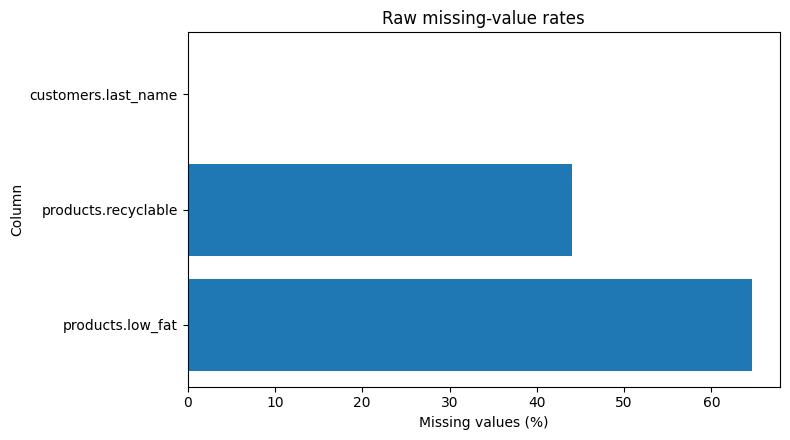

In [5]:
plt.figure(figsize=(8, 4.5))
labels = missing_columns["table"] + "." + missing_columns["column"]
plt.barh(labels, missing_columns["missing_rate_pct"])
plt.title("Raw missing-value rates")
plt.xlabel("Missing values (%)")
plt.ylabel("Column")
plt.tight_layout()
plt.show()

The product flag columns use `1` for true and a blank cell for false. They will be converted to Boolean values rather than treated as unknown attributes. The only conventional missing value is one customer last name.

## Results

### 3. Quality findings

In [6]:
findings = results["quality_findings"]
findings[["severity", "dataset", "column_or_rule", "issue", "recommended_action"]]

,severity,dataset,column_or_rule,issue,recommended_action
0,High,transactions,Comparable store coverage by year,"Only 13 stores have transactions in 1997, compared with 24 in 1998.",Report total growth and same-store growth separately. Use the 13 stores present in both years as...
1,High,transactions,Missing transaction-row identifier,"The fact files do not contain a transaction ID, receipt ID, or order ID.",Create a surrogate row ID during cleaning. Do not report Total Orders or Average Order Value.
2,High,returns,Missing return and transaction identifiers,Returns cannot be linked to a customer or a specific sales row.,"Create a surrogate return row ID and limit return analysis to date, product, store, and aggregat..."
3,Medium,transactions,Exact-looking duplicate rows,9 rows repeat all available transaction fields.,Flag the rows but retain them until a source-level uniqueness rule is available.
4,Medium,returns,Exact-looking duplicate rows,5 rows repeat all available return fields.,Flag and review; do not deduplicate automatically.
5,Medium,calendar / transactions,Dates with no transaction rows,57 calendar dates have no sales rows: 42 in 1997 and 15 in 1998.,"Keep the complete calendar, show zero activity through the date dimension, and document the sour..."
6,Medium,customers,customer_postal_code data type,20 postal codes are four digits because the field was loaded as an integer.,Convert the field to text and left-pad four-digit values to five characters.
7,Low,products,recyclable binary encoding,687 blank values coexist with 1 values; the source uses blank as the false state.,"Map blank to False and 1 to True, then store as boolean."
8,Low,products,low_fat binary encoding,1008 blank values coexist with 1 values; the source uses blank as the false state.,"Map blank to False and 1 to True, then store as boolean."
9,Low,customers,last_name completeness,One customer record has no last name.,Keep the source value and use 'Unknown' only in the presentation layer if a full name is required.


### 4. Relationship and business-rule checks

In [7]:
integrity_checks = pd.Series(results["integrity"], name="failed_rows").to_frame()
integrity_checks

,failed_rows
transaction_product_orphans,0
transaction_customer_orphans,0
transaction_store_orphans,0
return_product_orphans,0
return_store_orphans,0
store_region_orphans,0
transaction_quantity_nonpositive,0
return_quantity_nonpositive,0
stock_date_after_transaction_date,0
transaction_before_store_open,0


All tested foreign-key and core business-rule checks returned zero failed rows. This includes product/customer/store/region coverage, date ordering, positive quantities, retail price above cost, store area rules, and customer child-count consistency.

### 5. Store coverage by year

In [8]:
transactions = results["tables"]["transactions"]
store_coverage = (
    transactions.groupby("source_year")["store_id"]
    .nunique()
    .rename("active_stores")
    .to_frame()
)
store_coverage

,active_stores
source_year,
1997,13
1998,24


In [9]:
same_store_ids = set(
    transactions.loc[transactions["source_year"] == 1997, "store_id"]
).intersection(
    set(transactions.loc[transactions["source_year"] == 1998, "store_id"])
)

{
    "same_store_count": len(same_store_ids),
    "same_store_ids": sorted(same_store_ids),
}

{'same_store_count': 13,
 'same_store_ids': [2, 3, 6, 7, 11, 13, 14, 15, 16, 17, 22, 23, 24]}

This is the most important analytical limitation in the dataset. The final dashboard should show both total-company growth and same-store growth so that store expansion is not mistaken for operational improvement.

### 6. Exact-looking duplicate rows

In [10]:
transaction_duplicate_mask = transactions.duplicated(
    ["transaction_date", "stock_date", "product_id", "customer_id", "store_id", "quantity"],
    keep=False,
)
transactions.loc[transaction_duplicate_mask].sort_values(
    ["transaction_date", "store_id", "customer_id", "product_id"]
).head(20)

,transaction_date,stock_date,product_id,customer_id,store_id,quantity,source_year
28560,1997-05-02,1997-05-01,290,1690,16,3,1997
28638,1997-05-02,1997-05-01,290,1690,16,3,1997
144309,1998-04-29,1998-04-22,468,9610,8,3,1998
144310,1998-04-29,1998-04-22,468,9610,8,3,1998
154802,1998-05-19,1998-05-15,784,6527,12,5,1998
154803,1998-05-19,1998-05-15,784,6527,12,5,1998
157000,1998-05-24,1998-05-19,426,77,7,4,1998
157001,1998-05-24,1998-05-19,426,77,7,4,1998
168747,1998-06-18,1998-06-11,1528,4731,18,3,1998
168748,1998-06-18,1998-06-11,1528,4731,18,3,1998


These rows are flagged for review but not removed. Without a receipt or transaction ID, two identical rows may be duplicate records or two legitimate repeated line items.

### 7. Calendar coverage

In [11]:
calendar = results["tables"]["calendar"]
activity_dates = set(transactions["transaction_date"])
missing_activity_dates = calendar.loc[~calendar["date"].isin(activity_dates), "date"]

missing_activity_dates.groupby(missing_activity_dates.dt.year).size().rename("dates_without_sales")

date
1997    42
1998    15
Name: dates_without_sales, dtype: int64

The calendar remains complete. Dates without transaction rows will be represented as zero activity in the model, not filled with estimated sales.

## Takeaways

The dataset passes the core integrity checks and is suitable for cleaning and modeling. The next stage will focus on explicit type conversion, row identifiers, binary flag conversion, postal-code formatting, and a documented treatment of duplicate-like rows.

The audit does not support deleting any source record yet. The raw files remain unchanged.